In [2]:
#!pip install keras
import keras

C:\Users\graci\anaconda3\lib\site-packages\scipy\__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [3]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [4]:
test_train_df = pd.read_csv("GOOG.csv")

In [5]:
test_train_df.head()

,symbol,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
0,GOOG,2016-06-14 00:00:00+00:00,718.27,722.47,713.1200,716.48,1306065,718.27,722.47,713.1200,716.48,1306065,0.0,1.0
1,GOOG,2016-06-15 00:00:00+00:00,718.92,722.98,717.3100,719.00,1214517,718.92,722.98,717.3100,719.00,1214517,0.0,1.0
2,GOOG,2016-06-16 00:00:00+00:00,710.36,716.65,703.2600,714.91,1982471,710.36,716.65,703.2600,714.91,1982471,0.0,1.0
3,GOOG,2016-06-17 00:00:00+00:00,691.72,708.82,688.4515,708.65,3402357,691.72,708.82,688.4515,708.65,3402357,0.0,1.0
4,GOOG,2016-06-20 00:00:00+00:00,693.71,702.48,693.4100,698.77,2082538,693.71,702.48,693.4100,698.77,2082538,0.0,1.0


In [6]:
test_train_df.describe()

,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
count,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03,1258.0,1258.0
mean,1216.317067,1227.430934,1204.176430,1215.260779,1.601590e+06,1216.317067,1227.430936,1204.176436,1215.260779,1.601590e+06,0.0,1.0
std,383.333358,387.570872,378.777094,382.446995,6.960172e+05,383.333358,387.570873,378.777099,382.446995,6.960172e+05,0.0,0.0
min,668.260000,672.300000,663.284000,671.000000,3.467530e+05,668.260000,672.300000,663.284000,671.000000,3.467530e+05,0.0,1.0
25%,960.802500,968.757500,952.182500,959.005000,1.173522e+06,960.802500,968.757500,952.182500,959.005000,1.173522e+06,0.0,1.0
50%,1132.460000,1143.935000,1117.915000,1131.150000,1.412588e+06,1132.460000,1143.935000,1117.915000,1131.150000,1.412588e+06,0.0,1.0
75%,1360.595000,1374.345000,1348.557500,1361.075000,1.812156e+06,1360.595000,1374.345000,1348.557500,1361.075000,1.812156e+06,0.0,1.0
max,2521.600000,2526.990000,2498.290000,2524.920000,6.207027e+06,2521.600000,2526.990000,2498.290000,2524.920000,6.207027e+06,0.0,1.0


In [13]:
# new_df = test_train_df.iloc[:, 2:6].values 
new_df = test_train_df[["close", "high", "low","open"]]

In [14]:
new_df

,close,high,low,open
0,718.27,722.470,713.1200,716.48
1,718.92,722.980,717.3100,719.00
2,710.36,716.650,703.2600,714.91
3,691.72,708.820,688.4515,708.65
4,693.71,702.480,693.4100,698.77
...,...,...,...,...
1253,2466.09,2468.000,2441.0725,2451.32
1254,2482.85,2494.495,2468.2400,2479.90
1255,2491.40,2505.000,2487.3300,2499.50
1256,2521.60,2523.260,2494.0000,2494.01


In [15]:
new_df.shape

(1258, 4)

In [16]:
y = new_df['close']      # target variable
x = new_df.drop('close', axis = 1)

In [17]:
x_train, x_test = x[0:1000], x [1000:]   # 1006 = 80% of the rows 
y_train, y_test = y[0:1000], y [1000:]

In [18]:
#!pip install tensorflow

In [19]:
from keras.models import Sequential    # create one layer after other 'sequential'
from keras.layers import Dense


model = Sequential()
model.add(Dense(units=3, activation='relu', input_dim=x_train.shape[1]))  # smal network, 3 neurons on the ocult layer
model.add(Dense(units=1, activation='linear'))

In [20]:
#training the model
model.compile(loss='mse', optimizer='adam', metrics=['mae'])
result = model.fit(x_train, y_train, epochs=200, batch_size=32, validation_data=(x_test, y_test))

Epoch 1/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 10354420.0000 - mae: 3168.1047 - val_loss: 27266912.0000 - val_mae: 5140.9395
Epoch 2/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8860590.0000 - mae: 2929.1934 - val_loss: 23154280.0000 - val_mae: 4737.3784
Epoch 3/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7477534.5000 - mae: 2689.5898 - val_loss: 19456852.0000 - val_mae: 4342.6631
Epoch 4/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6270326.5000 - mae: 2464.6997 - val_loss: 16180207.0000 - val_mae: 3960.1260
Epoch 5/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5146774.0000 - mae: 2233.5422 - val_loss: 13283793.0000 - val_mae: 3588.1821
Epoch 6/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 4226035.0000 - mae: 2022.1494 - val_loss: 10736853.0000 - val_mae: 3225.8767
Epoch 7/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3402683.7500 - mae: 1815.7952 - val_loss: 8540545.0000 - val_mae: 2877.0476
Epoch 8/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/st

Epoch 52/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 54.5151 - mae: 4.5185 - val_loss: 138.9156 - val_mae: 8.9193
Epoch 53/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 49.1227 - mae: 4.4457 - val_loss: 138.8651 - val_mae: 8.9193
Epoch 54/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 52.9962 - mae: 4.6804 - val_loss: 138.9398 - val_mae: 8.9192
Epoch 55/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 58.5155 - mae: 4.7920 - val_loss: 138.9875 - val_mae: 8.9192
Epoch 56/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 52.5697 - mae: 4.7827 - val_loss: 138.9985 - val_mae: 8.9192
Epoch 57/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 47.0438 - mae: 4.3874 - val_loss: 138.8555 - val_mae: 8.9192
Epoch 58/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 49.7909 - mae: 4.5167 - val_loss: 139.0597 - val_mae: 8.9191
Epoch 59/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 49.8051 - mae: 4.4421 - val_loss: 138.8244 - val_mae: 8.9193
Epoch 60/200
32/32 ━━━━━━━━━━━━━

Epoch 105/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 53.4887 - mae: 4.7720 - val_loss: 138.5847 - val_mae: 8.9184
Epoch 106/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 52.4794 - mae: 4.4306 - val_loss: 139.2608 - val_mae: 8.9184
Epoch 107/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 49.9801 - mae: 4.6874 - val_loss: 138.7179 - val_mae: 8.9182
Epoch 108/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 60.6595 - mae: 4.6391 - val_loss: 138.5587 - val_mae: 8.9183
Epoch 109/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 46.8608 - mae: 4.3872 - val_loss: 138.8647 - val_mae: 8.9180
Epoch 110/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 47.4320 - mae: 4.3373 - val_loss: 138.1821 - val_mae: 8.9206
Epoch 111/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 47.7922 - mae: 4.5918 - val_loss: 138.5611 - val_mae: 8.9182
Epoch 112/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 41.4206 - mae: 4.3709 - val_loss: 139.0414 - val_mae: 8.9178
Epoch 113/200
32/32 ━━━━

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 47.4305 - mae: 4.3802 - val_loss: 140.9407 - val_mae: 8.9337
Epoch 158/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 50.2242 - mae: 4.4960 - val_loss: 138.9389 - val_mae: 8.9152
Epoch 159/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 49.1717 - mae: 4.2728 - val_loss: 138.0980 - val_mae: 8.9180
Epoch 160/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 43.4692 - mae: 4.3222 - val_loss: 138.4839 - val_mae: 8.9155
Epoch 161/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 42.7268 - mae: 4.4333 - val_loss: 137.9324 - val_mae: 8.9191
Epoch 162/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 61.3098 - mae: 4.6578 - val_loss: 138.4357 - val_mae: 8.9154
Epoch 163/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 45.7849 - mae: 4.4171 - val_loss: 138.0971 - val_mae: 8.9176
Epoch 164/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 37.6058 - mae: 4.2319 - val_loss: 138.0163 - val_mae: 8.9181
Epoch 165/200
32/32 ━━━━━━━━━━━━━━━━━━

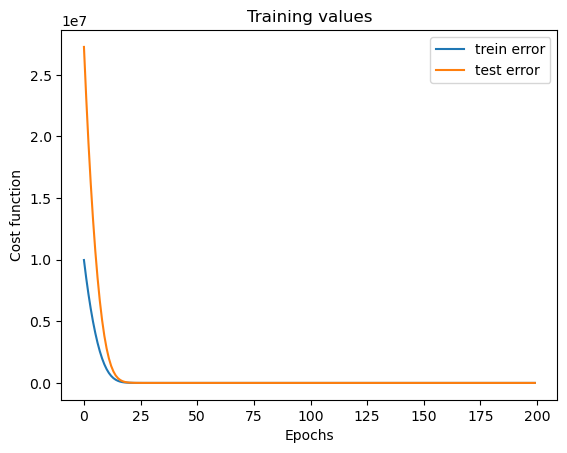

In [21]:
# visualize the training 
import matplotlib.pyplot as plt

plt.plot(result.history['loss'])  # plot loss
plt.plot(result.history['val_loss'])
plt.title('Training values')
plt.ylabel('Cost function')
plt.xlabel('Epochs')
plt.legend(['trein error', 'test error'])
plt.show()